# **1. Perkenalan Dataset**


Tahap pertama, Anda harus mencari dan menggunakan dataset dengan ketentuan sebagai berikut:

1. **Sumber Dataset**:  
   Dataset dapat diperoleh dari berbagai sumber, seperti public repositories (*Kaggle*, *UCI ML Repository*, *Open Data*) atau data primer yang Anda kumpulkan sendiri.



#### **Gambaran Umum Dataset**
Dataset yang digunakan dalam proyek ini adalah **Sleep Health and Lifestyle Dataset**.()(https://www.kaggle.com/datasets/uom190346a/sleep-health-and-lifestyle-dataset)Dataset ini terdiri dari **400 baris** dan **13 kolom**. Data ini mencakup berbagai variabel terkait tidur dan kebiasaan sehari-hari, termasuk jenis kelamin, usia, pekerjaan, durasi tidur, tingkat aktivitas fisik, tingkat stres, kategori BMI, tekanan darah, detak jantung, jumlah langkah harian, serta keberadaan gangguan tidur.

#### **Fitur Utama Dataset**
* **Metrik Tidur Komprehensif:** Mengeksplorasi durasi tidur, kualitas, dan faktor-faktor yang memengaruhi pola tidur.
* **Faktor Gaya Hidup:** Menganalisis tingkat aktivitas fisik, tingkat stres, dan kategori BMI.
* **Kesehatan Kardiovaskular:** Memeriksa pengukuran tekanan darah dan detak jantung.
* **Analisis Gangguan Tidur:** Mengidentifikasi terjadinya gangguan tidur seperti Insomnia dan *Sleep Apnea*.

#### **Deskripsi Kolom Data**
Berikut adalah penjelasan dari 13 kolom yang terdapat di dalam dataset:
1. **Person ID:** Pengenal identitas unik untuk setiap individu.
2. **Gender:** Jenis kelamin individu (Male/Female).
3. **Age:** Usia individu dalam hitungan tahun.
4. **Occupation:** Pekerjaan atau profesi dari individu.
5. **Sleep Duration (hours):** Jumlah jam individu tidur per hari.
6. **Quality of Sleep (scale: 1-10):** Penilaian subjektif terhadap kualitas tidur, dengan rentang skala 1 hingga 10.
7. **Physical Activity Level (minutes/day):** Durasi waktu (dalam menit) yang dihabiskan individu untuk aktivitas fisik setiap harinya.
8. **Stress Level (scale: 1-10):** Penilaian subjektif terhadap tingkat stres yang dialami, dengan rentang skala 1 hingga 10.
9. **BMI Category:** Kategori Indeks Massa Tubuh (BMI) individu (contoh: Underweight, Normal, Overweight).
10. **Blood Pressure (systolic/diastolic):** Pengukuran tekanan darah individu, yang ditunjukkan sebagai tekanan sistolik per tekanan diastolik.
11. **Heart Rate (bpm):** Detak jantung istirahat dalam satuan detak per menit (*beats per minute*).
12. **Daily Steps:** Jumlah langkah yang diambil oleh individu per hari.
13. **Sleep Disorder:** Menunjukkan ada atau tidaknya gangguan tidur pada individu. Terdiri dari 3 nilai:
   * **None:** Individu tidak menunjukkan gangguan tidur spesifik.
   * **Insomnia:** Individu mengalami kesulitan untuk mulai tidur atau mempertahankan tidur, sehingga kualitas tidurnya buruk.
   * **Sleep Apnea:** Individu mengalami jeda napas saat tidur, yang mengakibatkan pola tidur terganggu dan berisiko bagi kesehatan.

# **2. Import Library**

Pada tahap ini, Anda perlu mengimpor beberapa pustaka (library) Python yang dibutuhkan untuk analisis data dan pembangunan model machine learning atau deep learning.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# **3. Memuat Dataset**

Pada tahap ini, Anda perlu memuat dataset ke dalam notebook. Jika dataset dalam format CSV, Anda bisa menggunakan pustaka pandas untuk membacanya. Pastikan untuk mengecek beberapa baris awal dataset untuk memahami strukturnya dan memastikan data telah dimuat dengan benar.

Jika dataset berada di Google Drive, pastikan Anda menghubungkan Google Drive ke Colab terlebih dahulu. Setelah dataset berhasil dimuat, langkah berikutnya adalah memeriksa kesesuaian data dan siap untuk dianalisis lebih lanjut.

Jika dataset berupa unstructured data, silakan sesuaikan dengan format seperti kelas Machine Learning Pengembangan atau Machine Learning Terapan

In [2]:
df = pd.read_csv("../Sleep_health_and_lifestyle_dataset.csv")
df.head()

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 374 entries, 0 to 373
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Person ID                374 non-null    int64  
 1   Gender                   374 non-null    object 
 2   Age                      374 non-null    int64  
 3   Occupation               374 non-null    object 
 4   Sleep Duration           374 non-null    float64
 5   Quality of Sleep         374 non-null    int64  
 6   Physical Activity Level  374 non-null    int64  
 7   Stress Level             374 non-null    int64  
 8   BMI Category             374 non-null    object 
 9   Blood Pressure           374 non-null    object 
 10  Heart Rate               374 non-null    int64  
 11  Daily Steps              374 non-null    int64  
 12  Sleep Disorder           155 non-null    object 
dtypes: float64(1), int64(7), object(5)
memory usage: 38.1+ KB


In [4]:
df['Sleep Disorder'] = df['Sleep Disorder'].fillna('None')

# **4. Exploratory Data Analysis (EDA)**

Pada tahap ini, Anda akan melakukan **Exploratory Data Analysis (EDA)** untuk memahami karakteristik dataset.

Tujuan dari EDA adalah untuk memperoleh wawasan awal yang mendalam mengenai data dan menentukan langkah selanjutnya dalam analisis atau pemodelan.

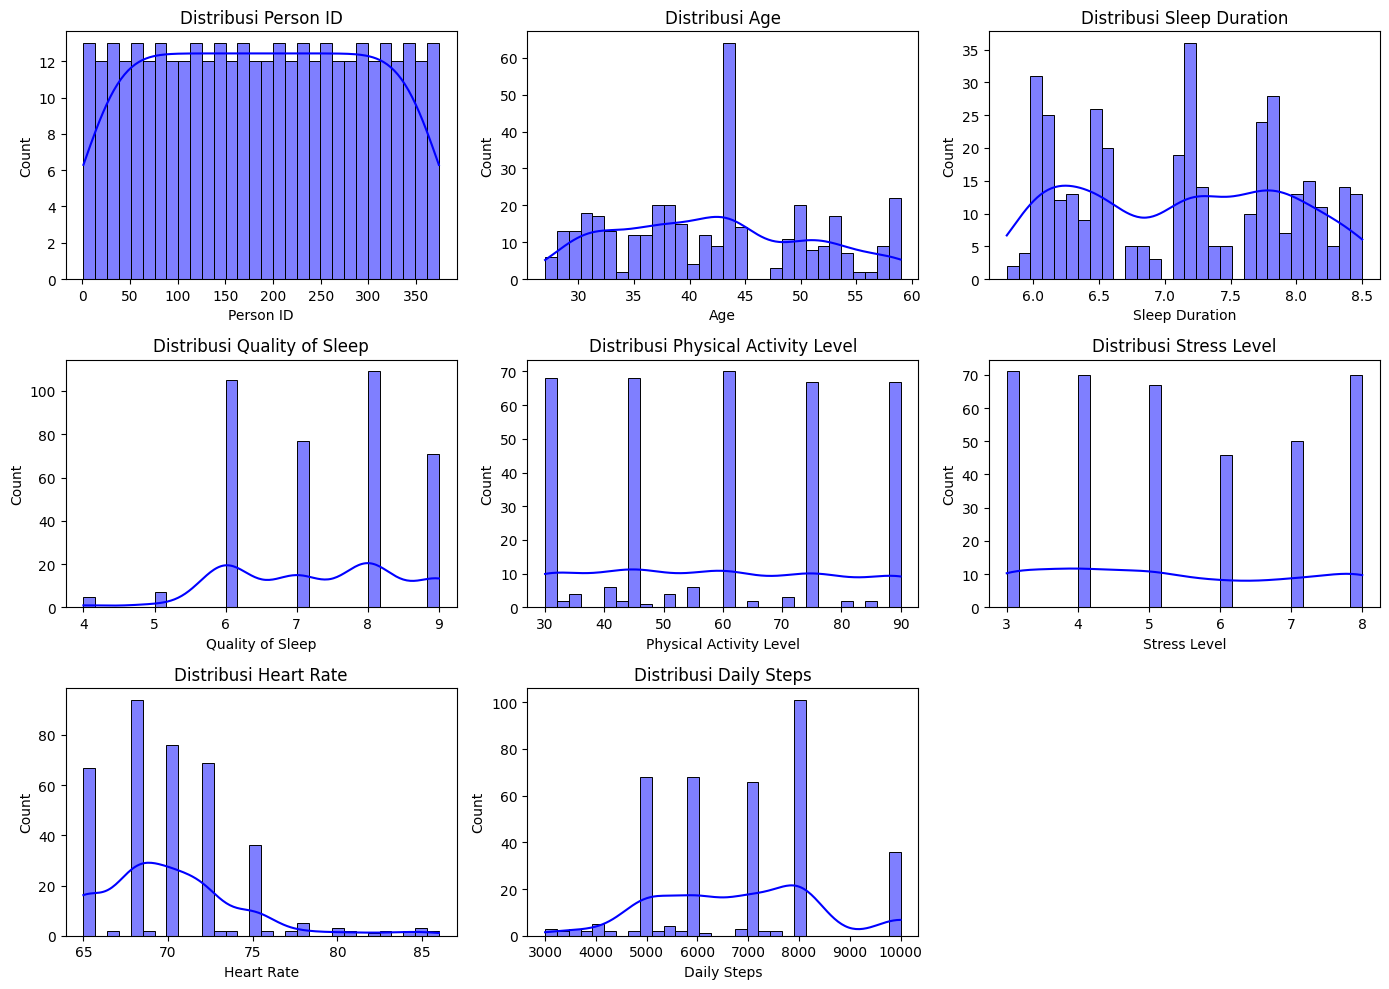

In [5]:
num_features = df.select_dtypes(include=[np.number])
plt.figure(figsize=(14,10))
for i, column in enumerate(num_features.columns,1):
  plt.subplot(3,3,i)
  sns.histplot(data=df[column], bins=30, kde=True, color='blue')
  plt.title(f"Distribusi {column}")
plt.tight_layout()
plt.show()

C:\Users\saban\AppData\Local\Temp\ipykernel_6696\2178856086.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[column], palette='viridis')
C:\Users\saban\AppData\Local\Temp\ipykernel_6696\2178856086.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[column], palette='viridis')
C:\Users\saban\AppData\Local\Temp\ipykernel_6696\2178856086.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y=df[column], palette='viridis')
C:\Users\saban\AppData\Local\Temp\ipykernel_6696\2178856086.py:5: FutureWarning: 

Passing `palette` witho

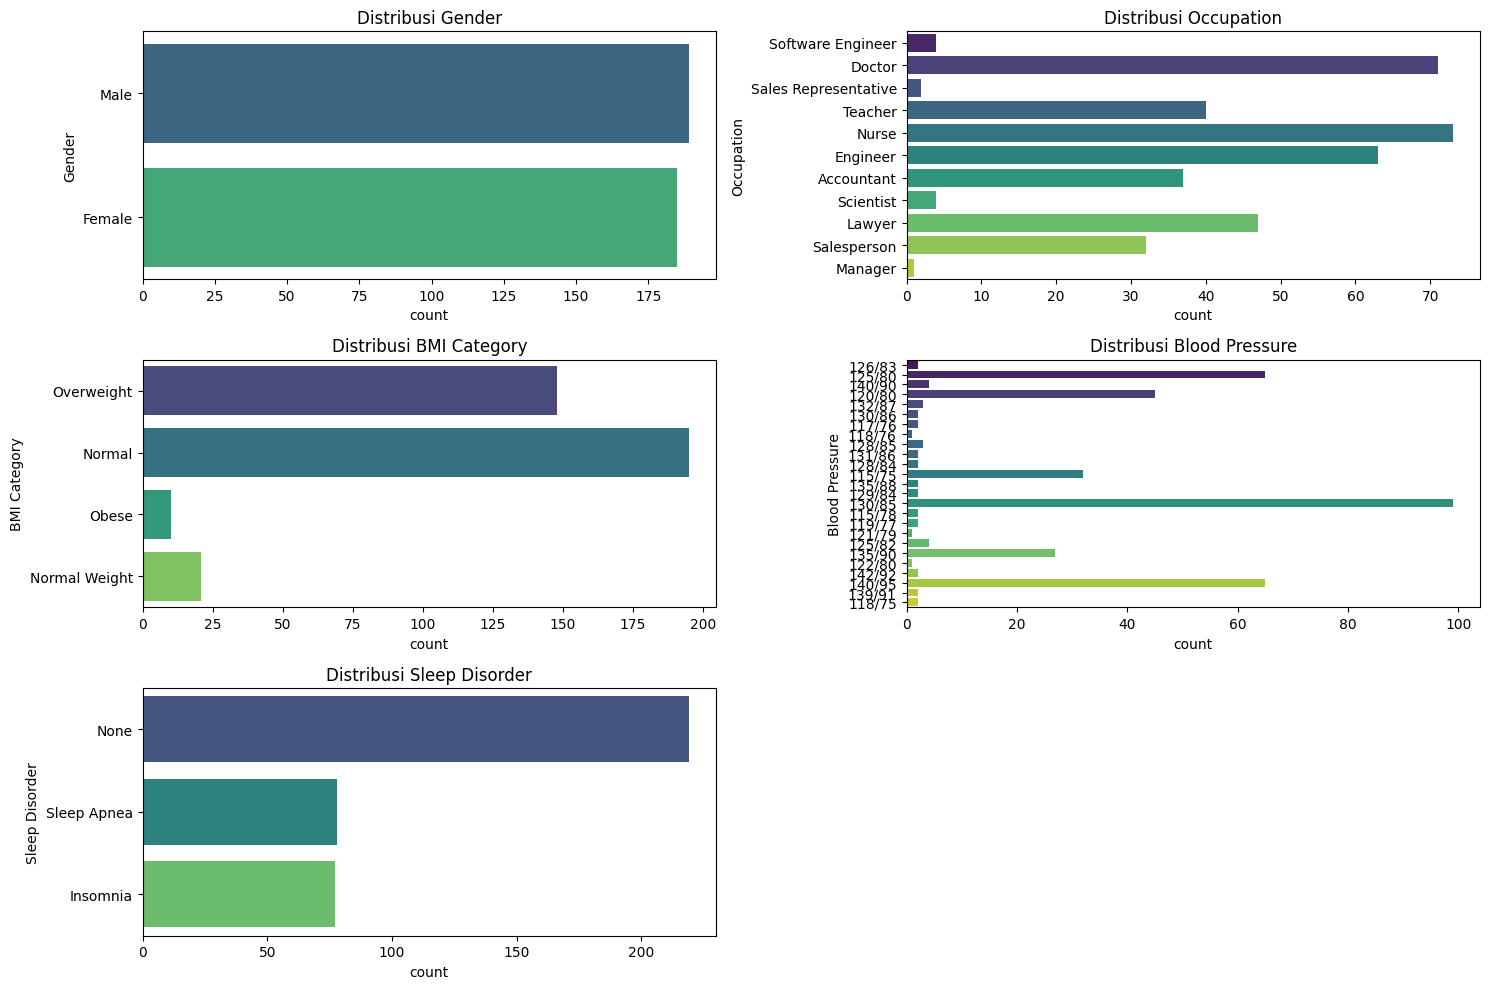

In [6]:
category_features = df.select_dtypes(include=[object])
plt.figure(figsize=(15, 10))
for i, column in enumerate(category_features.columns, 1):
  plt.subplot(3,2,i)
  sns.countplot(y=df[column], palette='viridis')
  plt.title(f"Distribusi {column}")
plt.tight_layout()
plt.show()

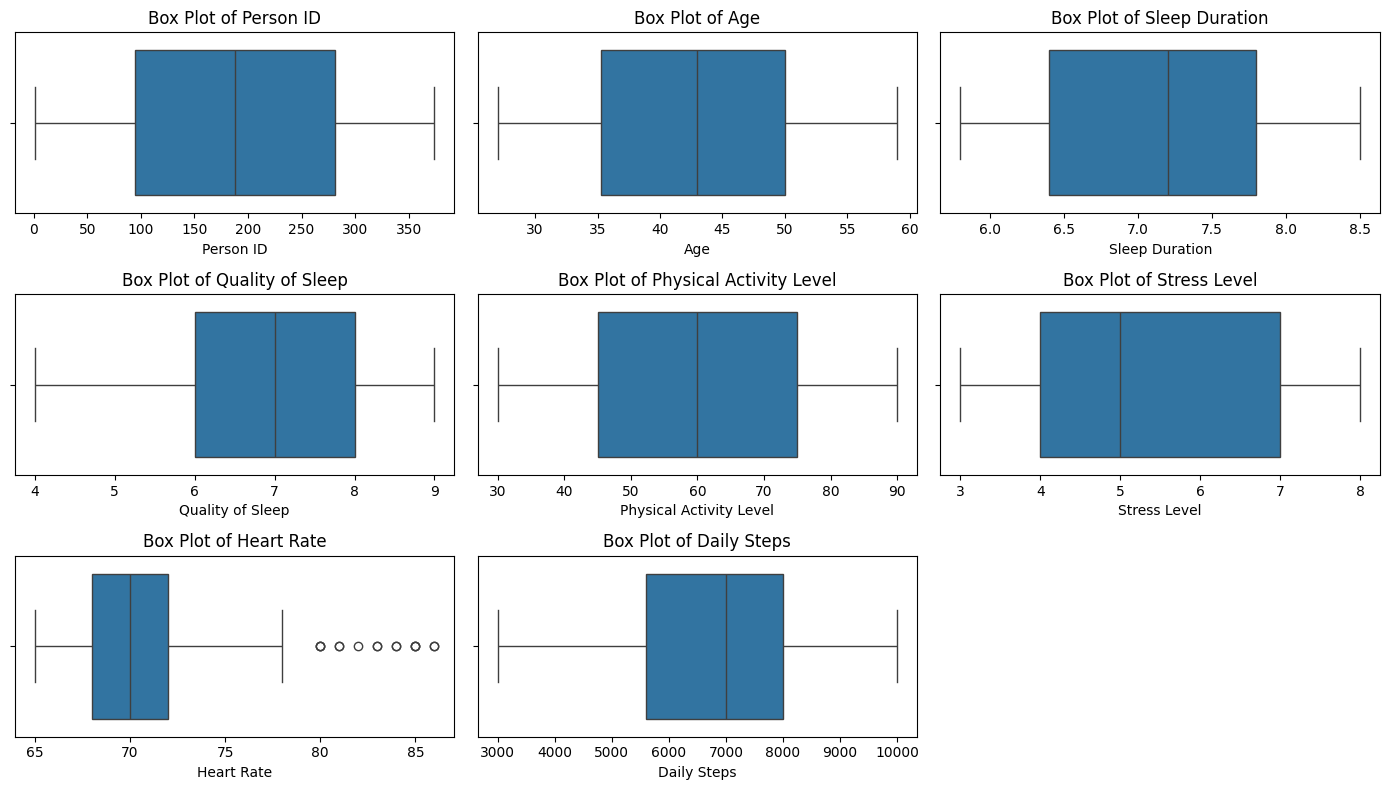

In [7]:
plt.figure(figsize=(14,8))
for i,feature in enumerate(num_features.columns,1):
    plt.subplot(3,3,i)
    sns.boxplot(x=df[feature])
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

# **5. Data Preprocessing**

Pada tahap ini, data preprocessing adalah langkah penting untuk memastikan kualitas data sebelum digunakan dalam model machine learning.

Jika Anda menggunakan data teks, data mentah sering kali mengandung nilai kosong, duplikasi, atau rentang nilai yang tidak konsisten, yang dapat memengaruhi kinerja model. Oleh karena itu, proses ini bertujuan untuk membersihkan dan mempersiapkan data agar analisis berjalan optimal.

Berikut adalah tahapan-tahapan yang bisa dilakukan, tetapi **tidak terbatas** pada:
1. Menghapus atau Menangani Data Kosong (Missing Values)
2. Menghapus Data Duplikat
3. Normalisasi atau Standarisasi Fitur
4. Deteksi dan Penanganan Outlier
5. Encoding Data Kategorikal
6. Binning (Pengelompokan Data)

Cukup sesuaikan dengan karakteristik data yang kamu gunakan yah. Khususnya ketika kami menggunakan data tidak terstruktur.

### Penanganan Outlier
Berdasarkan visualisasi boxplot, terdapat beberapa nilai ekstrem pada fitur numerik. 
Namun, karena dataset ini merupakan data kesehatan (sleep health & lifestyle), 
nilai-nilai tersebut dianggap valid secara medis dan mencerminkan kondisi nyata 
dari individu. Oleh karena itu, outlier tidak dihapus untuk menjaga integritas data.

In [8]:
print(df.isnull().sum())

Person ID                  0
Gender                     0
Age                        0
Occupation                 0
Sleep Duration             0
Quality of Sleep           0
Physical Activity Level    0
Stress Level               0
BMI Category               0
Blood Pressure             0
Heart Rate                 0
Daily Steps                0
Sleep Disorder             0
dtype: int64


In [9]:
duplikat_id = df[df.duplicated(subset=['Person ID'], keep=False)]
print(duplikat_id.sort_values(by='Person ID'))

Empty DataFrame
Columns: [Person ID, Gender, Age, Occupation, Sleep Duration, Quality of Sleep, Physical Activity Level, Stress Level, BMI Category, Blood Pressure, Heart Rate, Daily Steps, Sleep Disorder]
Index: []


In [10]:
df.drop(columns=['Person ID'], inplace=True)

In [11]:
df[['Systolic_BP', 'Diastolic_BP']] = df['Blood Pressure'].str.split('/', expand=True)
df['Systolic_BP'] = df['Systolic_BP'].astype(int)
df['Diastolic_BP'] = df['Diastolic_BP'].astype(int)
df.drop(columns=['Blood Pressure'], inplace=True)

In [12]:
df['BMI Category'] = df['BMI Category'].replace('Normal Weight', 'Normal')
bmi_mapping = {'Normal' : 1, 'Overweight' : 2, 'Obese' : 3}
df['BMI Category'] = df['BMI Category'].map(bmi_mapping)

In [13]:
le_target = LabelEncoder()
df['Sleep Disorder'] = le_target.fit_transform((df['Sleep Disorder']))

In [14]:
X = df.drop(columns='Sleep Disorder')
y = df['Sleep Disorder']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [15]:
cat_encode = ['Gender', 'Occupation']
encoders = {}
for col in  cat_encode:
  le = LabelEncoder()
  X_train[col] = le.fit_transform(X_train[col])
  X_test[col] = le.transform(X_test[col])
  encoders[col] = le

In [16]:
numeric_features = X_train.select_dtypes(include=[np.number]).columns
scaler = StandardScaler()
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

In [17]:
feature_names = list(numeric_features) + cat_encode
df_result = pd.DataFrame(X_train, columns=feature_names)
df_result['Sleep Disorder'] = y_train.values

In [18]:
output_path = 'data_preprocessing.csv'
df_result.to_csv(output_path, index=False)
print(f"Data preprocessed berhasil disimpan di: {output_path}")

df_header = pd.DataFrame(columns=feature_names)
df_header.to_csv('data.csv', index=False)

Data preprocessed berhasil disimpan di: data_preprocessing.csv
